# Report Generator
### Setup and Import

In [15]:
# Make sure plotly works
import plotly.io as pio
pio.renderers.default = 'iframe' 

In [1]:
# --- Configuration & Imports ---
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys

def load_file(file_path):
    """Load and validate the CSV file"""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File '{file_path}' not found. Please check path.")
    print(f"Loading data from: {file_path}")
    return pd.read_csv(file_path)

### User Input

In [2]:
# --- Get User Input for File Path ---
try:
    user_input = input("Enter the CSV file name (e.g., sales.csv): ").strip()
    if not user_input:
        raise ValueError("No filename provided.")
except Exception as e:
    print(f"Error during input: {e}")
    # Fallback for automation testing without user interaction
    if len(sys.argv) > 1:
        user_input = sys.argv[1]
    
# Define the data source variable
input_file = user_input

Enter the CSV file name (e.g., sales.csv):  retail_sales_dataset.csv


### Data Cleaning

In [3]:
# --- Automate Data Cleaning ---
def clean_dataframe(df):
    if df is None: return None

    print("Cleaning missing values...")

    initial_count = len(df)
    
    # Convert Date strings to datetime objects for time-series analysis
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    
    # Dynamically identify ALL numeric columns
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    
    print(f"Identified {len(numeric_cols)} numeric columns to process...")

    # 2. Clean and Fill Medians for each numeric column found
    for col in numeric_cols:
        if df[col].isna().any(): # Only fill if there are actually missing values
            median_val = df[col].median()
            print(f"Filling missing values in '{col}' with median ({median_val})")
            df[col] = df[col].fillna(median_val)

    print(f"Rows remaining: {len(df)} / {initial_count}")
    
    return df

clean_df = clean_dataframe(load_file(input_file))

Loading data from: retail_sales_dataset.csv
Cleaning missing values...
Identified 5 numeric columns to process...
Rows remaining: 1000 / 1000


In [39]:
clean_df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


### Analysis & Metrics

In [5]:
# --- Generate Key Metrics ---
def analyze_sales(df):
    print("Generating Sales Insights...")
    
    # 1. Calculate Revenue per Category
    category_summary = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
    
    # 2. Total Transactions per Gender
    gender_stats = df.groupby('Gender').agg({
        'Transaction ID': 'count',
        'Total Amount': 'sum'
    }).rename(columns={'Transaction ID': 'Count', 'Total Amount': 'Revenue'})

    print("Finished")
    
    return category_summary, gender_stats

metrics = analyze_sales(clean_df)

Generating Sales Insights...
Finished


In [6]:
metrics

(Product Category
 Electronics    156905
 Clothing       155580
 Beauty         143515
 Name: Total Amount, dtype: int64,
         Count  Revenue
 Gender                
 Female    510   232840
 Male      490   223160)

### Visualization

Generating Sales Insights...
Finished
Report saved to: sales_report.png

 Key Insights:
  - Electronics: $156,905.00
  - Clothing: $155,580.00
  - Beauty: $143,515.00


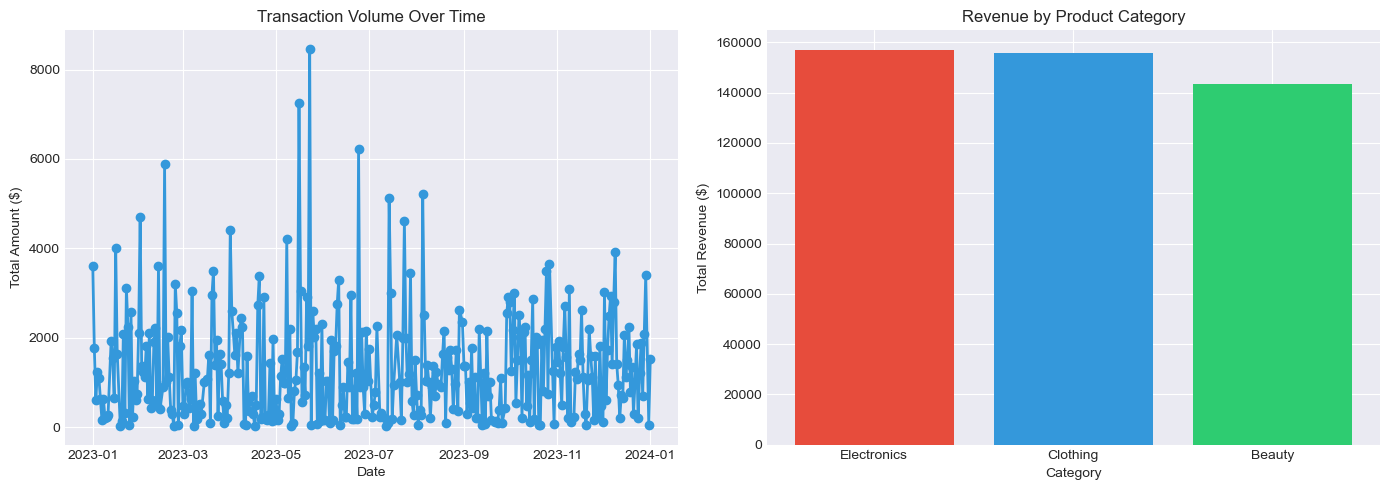

In [7]:
# --- Generate Dashboard/Report Chart ---
def visualize_sales(df):
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Chart 1: Total Amount Over Time (Line Chart)
    if 'Date' in df.columns and 'Total Amount' in df.columns:
        daily_sales = df.groupby('Date')['Total Amount'].sum()
        axes[0].plot(daily_sales.index, daily_sales.values, marker='o', linewidth=2, color='#3498db')
        axes[0].set_title("Transaction Volume Over Time")
        axes[0].set_xlabel("Date")
        axes[0].set_ylabel("Total Amount ($)")
    
    # Chart 2: Revenue by Product Category (Bar Chart)
    category_summary, _ = analyze_sales(df)
    colors = ['#e74c3c', '#3498db', '#2ecc71']
    axes[1].bar(category_summary.index, category_summary.values, color=colors)
    axes[1].set_title("Revenue by Product Category")
    axes[1].set_xlabel("Category")
    axes[1].set_ylabel("Total Revenue ($)")

    plt.tight_layout()
    save_path = 'sales_report.png'
    plt.savefig(save_path)
    print(f"Report saved to: {save_path}")
    
    # Print Summary Text
    print("\n Key Insights:")
    for cat, revenue in category_summary.items():
        print(f"  - {cat}: ${revenue:,.2f}")

visualize_sales(clean_df)

### Plotly Visualization

In [8]:
#pip install -U kaleido
#!pip install --upgrade plotly kaleido

In [66]:
import plotly.express as px
from plotly import graph_objects as go

def create_interactive_plots(df, file_name="Data Report"):
    """
    Generates interactive Plotly charts for data visualization.
    Input: clean_df (pandas DataFrame)
    Output: Interactive plots saved to PNG and HTML
    """
    try:
        # Check if dataframe is valid
        if df is None or len(df) == 0:
            print("No data available to visualize.")
            return None, None, None

        work_df = df.copy() # Do not modify original input dataframe

        # Sort Time Series Chronologically
        if 'Date' in work_df.columns:
            work_df = work_df.sort_values(by='Date').reset_index(drop=True)

        # Aggregate Categories for Revenue (Independent of time order)
        if 'Product Category' in work_df.columns and 'Total Amount' in work_df.columns:
            agg_df = work_df.groupby(['Product Category', 'Gender'])['Total Amount'].sum().reset_index()
        else:
            agg_df = None

        print(f"Generating interactive visualizations for '{file_name}'...")

        # Plot 1: Sales Trend Over Time (Line Chart)
        # Assumes 'Date' column exists and is datetime converted
        fig_time = px.line(work_df, x='Date', y='Total Amount', 
                           title="Daily Transaction Volume & Revenue",
                           labels={'Date': 'Transaction Date', 'Total Amount': 'Amount ($)'},
                           markers=True,
                           template='plotly_white') # Clean white background
        
        # Plot 2: Revenue by Category (Bar Chart)
        # Assumes 'Product Category' column exists
        if 'Product Category' in work_df.columns and 'Total Amount' in work_df.columns:
            fig_cat = px.bar(agg_df, x='Product Category', y='Total Amount', 
                             title="Revenue by Product Category",
                             labels={'Total Amount': 'Revenue ($)'},
                             color='Gender', # Color intensity by value
                             barmode='group')
        else:
            print("Warning: Required columns for category chart missing.")
            fig_cat = None

        # Plot 3: Sales Distribution (Histogram)
        # Assumes 'Quantity' column exists
        if 'Quantity' in work_df.columns and 'Product Category' in work_df.columns:
            fig_hist = px.histogram(work_df, x='Quantity',
                                    facet_col='Product Category', # Creates subplots per category (Beauty, Clothing, Electronics)
                                    nbins=5, # Controls bin width; 5 works well for low integer quantities like 1-4
                                    title="Purchase Quantity Distribution by Category",
                                    color='Product Category',
                                    template='plotly_white')
            fig_hist.update_traces(
                marker_line_color='black',   # The outline color (use 'white' if background is dark)
                marker_line_width=2,         # Thickness of the outline
            )
        else:
            print("Warning: Required columns for histogram missing.")
            fig_hist = None

        print("Visualizations generated successfully!")
        
        # Save images to disk
        if fig_time: fig_time.write_image("sales_trend.png")
        if fig_cat: fig_cat.write_image("category_revenue.png")
        if fig_hist: fig_hist.write_image("quantity_distribution.png")
        
        return fig_time, fig_cat, fig_hist

    except Exception as e:
        print(f"Error during visualization: {e}")
        return None, None, None

In [67]:
# Call and display the figures directly
fig_time, fig_cat, fig_hist = create_interactive_plots(clean_df)

Generating interactive visualizations for 'Data Report'...
Visualizations generated successfully!


In [44]:
fig_time.show() # Display line chart

In [45]:
fig_cat.show() # Display bar chart

In [61]:
fig_hist.show() # display histogram